In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH = Path('../../data/Berrocal_2020/Data/eve_data_longform_w_nuclei_060520_FILTERED.csv')

# Stripe AP coordinate ranges (from config.yaml, stripe_ranges section)
STRIPE_RANGES = {
    'stripe2': (0.3425, 0.4225),
    'stripe3': (0.4425, 0.5225),
    'stripe4': (0.5275, 0.5975),
}
STRIPE_COLORS = {
    'stripe2': '#E63946',
    'stripe3': '#2196F3',
    'stripe4': '#4CAF50',
}
STRIPE_LABELS = {
    'stripe2': 'Stripe 2',
    'stripe3': 'Stripe 3',
    'stripe4': 'Stripe 4',
}

# Random seed for reproducible nucleus sampling
RNG_SEED = 42
N_SAMPLE = 200    # max nuclei to plot per stripe in trajectory panels

print(f'Loading data from {DATA_PATH} ...')
df = pd.read_csv(DATA_PATH)
print(f'  rows: {len(df):,}   columns: {list(df.columns)}')
print(f'  time range: {df["time"].min()} – {df["time"].max()} s  '
      f'({df["time"].nunique()} time points)')
print(f'  nuclei: {df["nucleus_id"].nunique():,}')

Loading data from ../../data/Berrocal_2020/Data/eve_data_longform_w_nuclei_060520_FILTERED.csv ...
  rows: 430,073   columns: ['nucleus_id', 'particle_id', 'set_id', 'ap_raw', 'ap_registered', 'xPos', 'yPos', 'burst_stripe_id', 'time', 'fluo', 'inference_stripe_id', 'inference_fluo_id', 'v_state', 'v_fluo', 'embryo', 'movie', 'xPosF', 'yPosF']
  time range: 0 – 3000 s  (151 time points)
  nuclei: 2,959


In [5]:
# ── Assign nuclei to stripes based on *median* AP position ───────────────────
# Using median makes the assignment robust to transient excursions outside the stripe.

median_ap = df.groupby('nucleus_id')['ap_registered'].median().rename('median_ap')

def assign_stripe(ap):
    for s, (lo, hi) in STRIPE_RANGES.items():
        if lo <= ap <= hi:
            return s
    return None

median_ap_df = median_ap.reset_index()
median_ap_df['stripe'] = median_ap_df['median_ap'].apply(assign_stripe)

# Merge stripe assignment back onto long-form data
df = df.merge(median_ap_df[['nucleus_id', 'stripe', 'median_ap']], on='nucleus_id', how='left')
df_stripes = df.dropna(subset=['stripe'])

for s in STRIPE_RANGES:
    n = df_stripes[df_stripes['stripe'] == s]['nucleus_id'].nunique()
    print(f'  {s}: {n:,} nuclei')

  stripe2: 326 nuclei
  stripe3: 497 nuclei
  stripe4: 427 nuclei


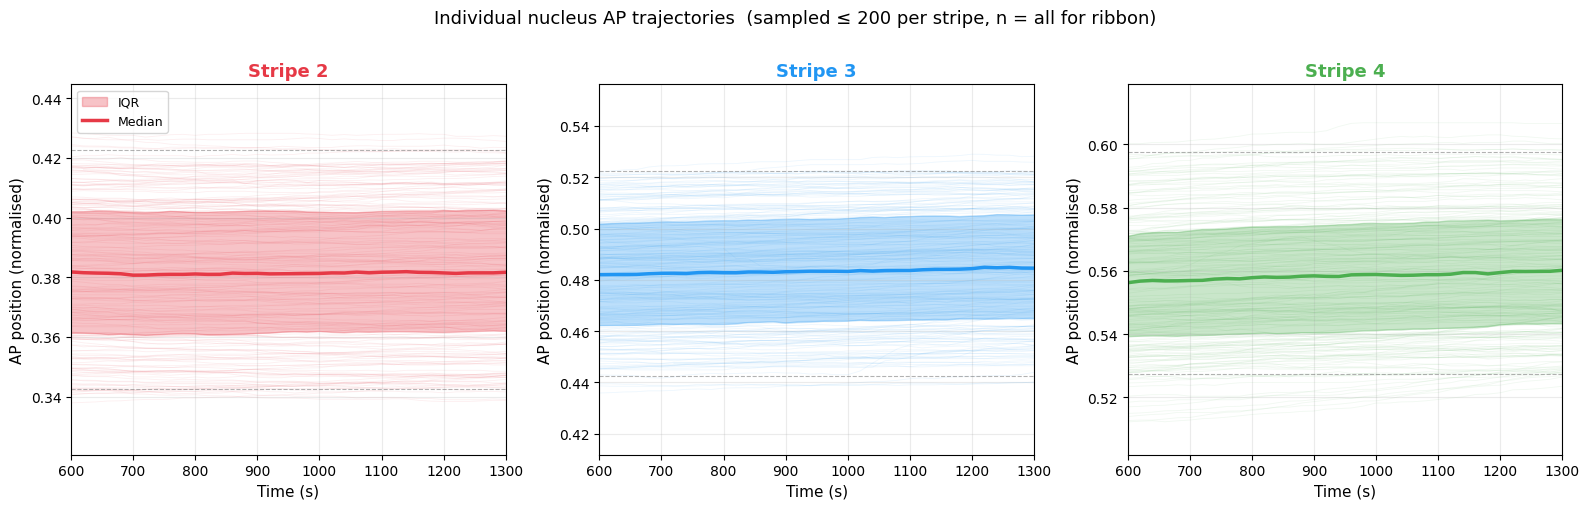

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure A  –  Individual nucleus AP trajectories
# ─────────────────────────────────────────────────────────────────────────────
# Each thin line is one nucleus tracked through time.
# Shaded ribbon = median ± IQR across all nuclei in that stripe.

rng = np.random.default_rng(RNG_SEED)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, stripe in zip(axes, STRIPE_RANGES):
    color = STRIPE_COLORS[stripe]
    lo, hi = STRIPE_RANGES[stripe]

    df_s = df_stripes[df_stripes['stripe'] == stripe]

    # Sample nuclei for plotting (too many lines → illegible)
    all_nuclei = df_s['nucleus_id'].unique()
    sampled = rng.choice(all_nuclei, size=min(N_SAMPLE, len(all_nuclei)), replace=False)

    # Plot individual trajectories
    for nid in sampled:
        traj = df_s[df_s['nucleus_id'] == nid][['time', 'ap_registered']].sort_values('time')
        ax.plot(traj['time'], traj['ap_registered'],
                color=color, alpha=0.08, linewidth=0.6, rasterized=True)

    # Median + IQR ribbon across ALL nuclei in stripe, per timepoint
    summary = (
        df_s.groupby('time')['ap_registered']
        .agg(median='median',
             q25=lambda x: x.quantile(0.25),
             q75=lambda x: x.quantile(0.75))
        .reset_index()
        .sort_values('time')
    )

    ax.fill_between(summary['time'], summary['q25'], summary['q75'],
                    color=color, alpha=0.3, label='IQR')
    ax.plot(summary['time'], summary['median'],
            color=color, linewidth=2.5, label='Median')

    # Mark the stripe AP range
    ax.axhline(lo, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axhline(hi, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)

    ax.set_title(STRIPE_LABELS[stripe], fontsize=13, color=color, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('AP position (normalised)', fontsize=11)
    ax.set_xlim(600,1300) #df_stripes['time'].min(), df_stripes['time'].max())
    ax.grid(True, alpha=0.25)

    # Legend only on first panel
    if ax is axes[0]:
        ax.legend(fontsize=9, loc='upper left')

fig.suptitle(
    f'Individual nucleus AP trajectories  (sampled ≤ {N_SAMPLE} per stripe, n = all for ribbon)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

/tmp/slurm.11929130/ipykernel_221691/266537034.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


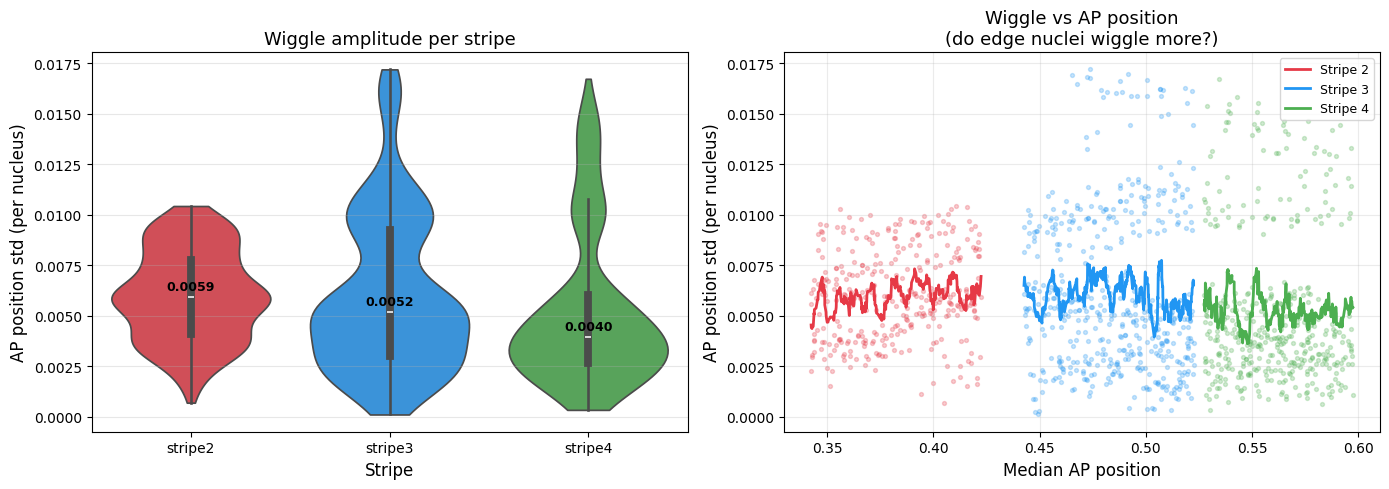


Wiggle amplitude summary (AP std per nucleus):
         count     mean      std      min      25%      50%      75%      max
stripe                                                                       
stripe2  326.0  0.00600  0.00224  0.00070  0.00411  0.00595  0.00777  0.01044
stripe3  497.0  0.00610  0.00393  0.00011  0.00300  0.00518  0.00927  0.01721
stripe4  427.0  0.00524  0.00379  0.00034  0.00265  0.00396  0.00602  0.01674


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure B  –  Wiggle amplitude distribution
# ─────────────────────────────────────────────────────────────────────────────
# Per-nucleus AP standard deviation across all recorded frames.
# Higher std = more positional jitter / drift.
# Right panel: wiggle vs median AP position (do edge nuclei wiggle more?).

wiggle = (
    df_stripes.groupby(['nucleus_id', 'stripe'])['ap_registered']
    .agg(wiggle_std='std', median_ap='median', n_frames='count')
    .reset_index()
)
# Require at least 3 frames to estimate std meaningfully
wiggle = wiggle[wiggle['n_frames'] >= 3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: violin plot of wiggle amplitude per stripe ─────────────────────
ax = axes[0]
stripe_order = list(STRIPE_RANGES.keys())
palette = {s: STRIPE_COLORS[s] for s in stripe_order}

sns.violinplot(
    data=wiggle, x='stripe', y='wiggle_std', order=stripe_order,
    palette=palette, inner='box', cut=0, ax=ax
)
ax.set_xlabel('Stripe', fontsize=12)
ax.set_ylabel('AP position std (per nucleus)', fontsize=12)
ax.set_title('Wiggle amplitude per stripe', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)

# Annotate medians
for i, s in enumerate(stripe_order):
    med = wiggle[wiggle['stripe'] == s]['wiggle_std'].median()
    ax.text(i, med + 0.0002, f'{med:.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='black')

# ── Panel 2: wiggle vs median AP position ───────────────────────────────────
ax = axes[1]
for s in stripe_order:
    w = wiggle[wiggle['stripe'] == s]
    ax.scatter(w['median_ap'], w['wiggle_std'],
               color=STRIPE_COLORS[s], alpha=0.25, s=8, rasterized=True)
    # Smoothed trend (rolling mean on sorted data)
    w_sorted = w.sort_values('median_ap')
    window = max(5, len(w_sorted) // 20)
    ax.plot(w_sorted['median_ap'],
            w_sorted['wiggle_std'].rolling(window, center=True, min_periods=3).mean(),
            color=STRIPE_COLORS[s], linewidth=2, label=STRIPE_LABELS[s])

ax.set_xlabel('Median AP position', fontsize=12)
ax.set_ylabel('AP position std (per nucleus)', fontsize=12)
ax.set_title('Wiggle vs AP position\n(do edge nuclei wiggle more?)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print('\nWiggle amplitude summary (AP std per nucleus):')
print(wiggle.groupby('stripe')['wiggle_std'].describe().round(5).to_string())

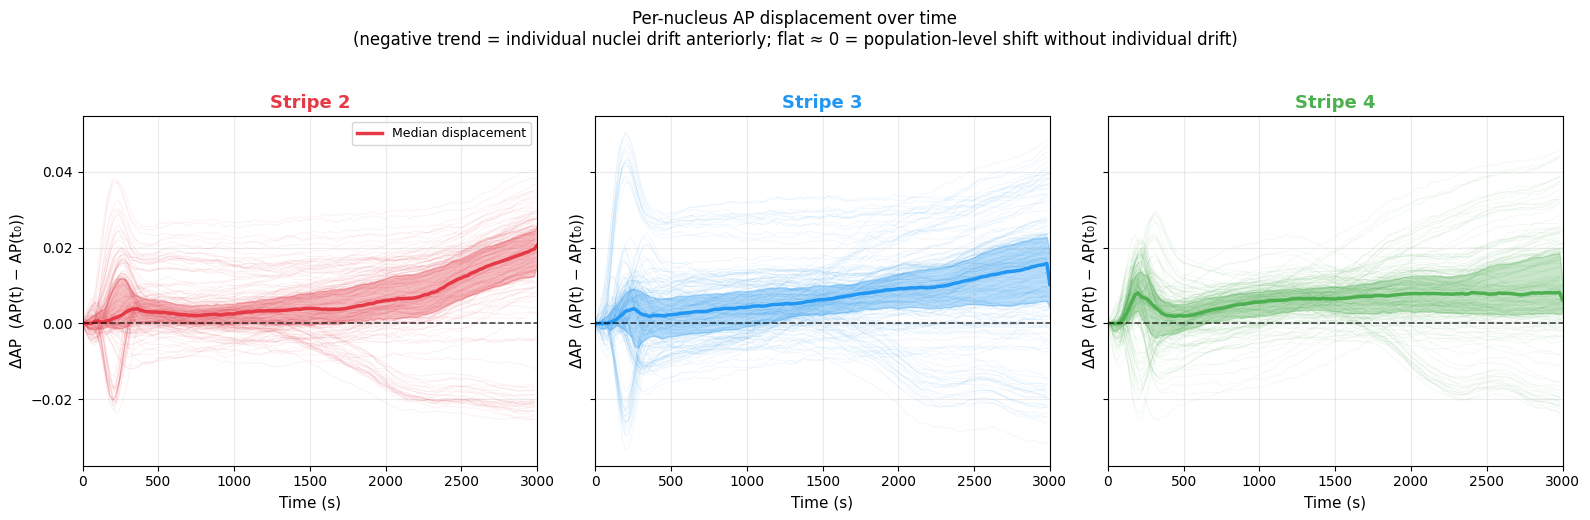


Median net displacement at t_max:
  stripe2: median Δap = +0.02063  (n=128 nuclei)
  stripe3: median Δap = +0.01031  (n=213 nuclei)
  stripe4: median Δap = +0.00628  (n=214 nuclei)


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure C  –  Displacement over time  (drift vs jitter)
# ─────────────────────────────────────────────────────────────────────────────
# For each nucleus: Δap(t) = ap(t) − ap(t_first)
# If individual nuclei drift leftward, displacements trend negative.
# If the population-level leftward shift comes from compositional turnover
# (different nuclei entering / leaving the frame) but individual nuclei stay
# put, displacements will be ~flat around 0.

rng2 = np.random.default_rng(RNG_SEED + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, stripe in zip(axes, STRIPE_RANGES):
    color = STRIPE_COLORS[stripe]
    df_s = df_stripes[df_stripes['stripe'] == stripe].copy()

    # Compute displacement relative to each nucleus's first recorded frame
    df_s = df_s.sort_values(['nucleus_id', 'time'])
    df_s['ap_first'] = df_s.groupby('nucleus_id')['ap_registered'].transform('first')
    df_s['displacement'] = df_s['ap_registered'] - df_s['ap_first']

    # Sample nuclei for individual lines
    all_nuclei = df_s['nucleus_id'].unique()
    sampled = rng2.choice(all_nuclei, size=min(N_SAMPLE, len(all_nuclei)), replace=False)

    for nid in sampled:
        traj = df_s[df_s['nucleus_id'] == nid][['time', 'displacement']].sort_values('time')
        ax.plot(traj['time'], traj['displacement'],
                color=color, alpha=0.08, linewidth=0.6, rasterized=True)

    # Median ± IQR of displacement across all nuclei per timepoint
    summary = (
        df_s.groupby('time')['displacement']
        .agg(median='median',
             q25=lambda x: x.quantile(0.25),
             q75=lambda x: x.quantile(0.75))
        .reset_index()
        .sort_values('time')
    )
    ax.fill_between(summary['time'], summary['q25'], summary['q75'],
                    color=color, alpha=0.3)
    ax.plot(summary['time'], summary['median'],
            color=color, linewidth=2.5, label='Median displacement')

    # Zero-displacement reference
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)

    ax.set_title(STRIPE_LABELS[stripe], fontsize=13, color=color, fontweight='bold')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('ΔAP  (AP(t) − AP(t₀))', fontsize=11)
    ax.set_xlim(df_s['time'].min(), df_s['time'].max())
    ax.grid(True, alpha=0.25)
    if ax is axes[0]:
        ax.legend(fontsize=9)

fig.suptitle(
    'Per-nucleus AP displacement over time\n'
    '(negative trend = individual nuclei drift anteriorly; '
    'flat ≈ 0 = population-level shift without individual drift)',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.show()

# Summary: net displacement at final timepoint
t_max_data = df_stripes['time'].max()
print('\nMedian net displacement at t_max:')
for s in STRIPE_RANGES:
    df_s = df_stripes[df_stripes['stripe'] == s].copy()
    df_s['ap_first'] = df_s.groupby('nucleus_id')['ap_registered'].transform('first')
    df_s['displacement'] = df_s['ap_registered'] - df_s['ap_first']
    final = df_s[df_s['time'] == t_max_data]['displacement']
    print(f'  {s}: median Δap = {final.median():+.5f}  (n={len(final):,} nuclei)')

Nuclei tracked t=1000→1200: 2,959 total
AP displacement stats:
  dap  mean=0.00059  median=0.00047  max=0.01339
  stripe2: 326 nuclei  AP 0.3425–0.4225
  stripe3: 497 nuclei  AP 0.4425–0.5225
  stripe4: 416 nuclei  AP 0.5275–0.5975
  other: 1,720 nuclei


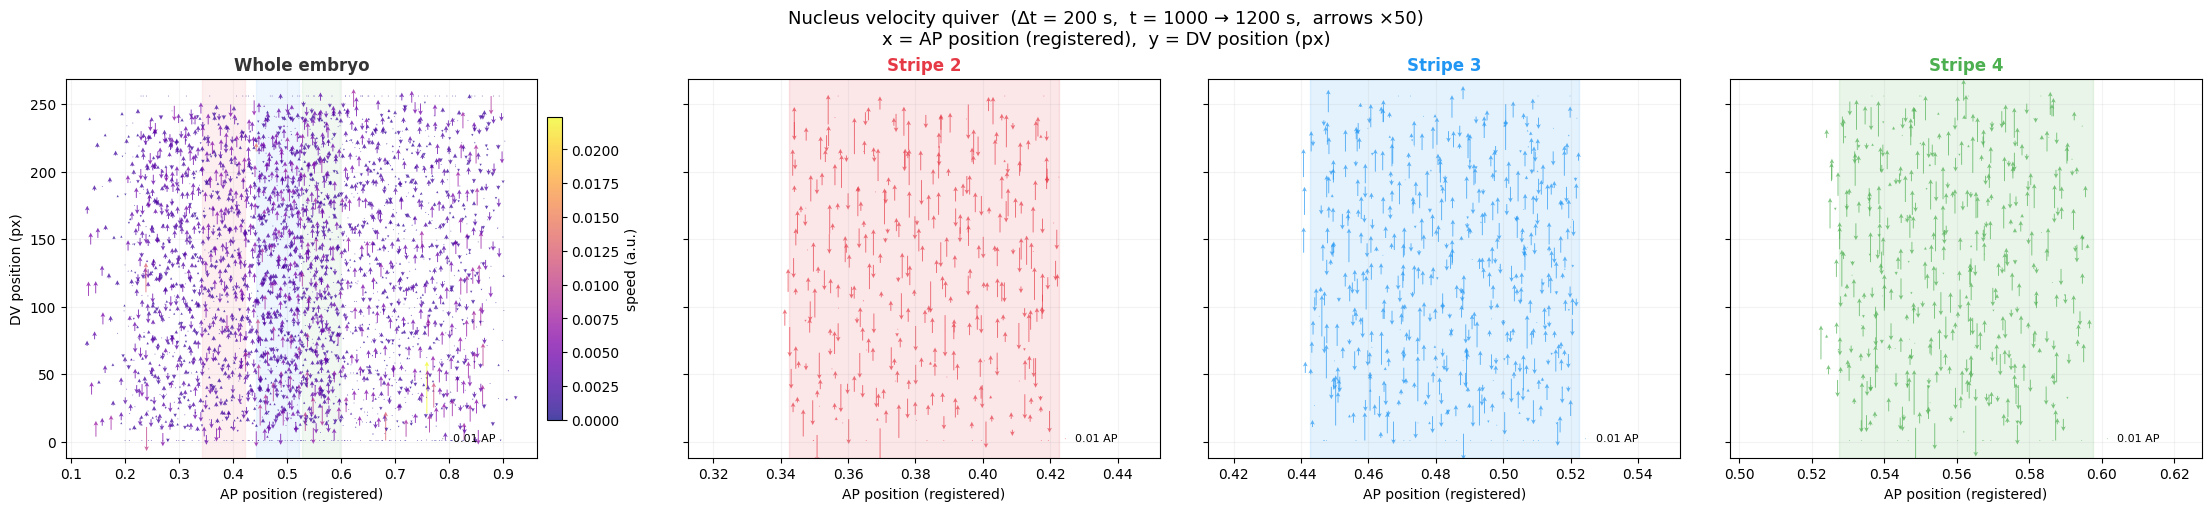

In [9]:

# ─────────────────────────────────────────────────────────────────────────────
# Figure D  –  Quiver plot of nucleus velocity at t = 1200 s
# ─────────────────────────────────────────────────────────────────────────────
# Velocity = displacement between t=1180 and t=1200 (Δt = 20 s).
# Axes: x = ap_registered, y = yPos (dorsal-ventral in pixels).
# Stripe membership assigned from AP position at t=1200 (not median).
# Layout: whole-embryo overview (coloured by speed) + one panel per stripe.

QUIVER_T1     = 1000   # start frame
QUIVER_T2     = 1200   # end frame  (Δt = 20 s)
ARROW_MAGNIFY = 50     # multiply displacements for visibility
                       # (AP displacements are ~0.001 units; DV in pixels ~1-5)

# ── Positions at both timepoints ─────────────────────────────────────────────
pos1 = (df[df['time'] == QUIVER_T1]
        .set_index('nucleus_id')[['ap_registered', 'yPos']]
        .rename(columns={'ap_registered': 'ap1', 'yPos': 'y1'}))

pos2 = (df[df['time'] == QUIVER_T2]
        .set_index('nucleus_id')[['ap_registered', 'yPos']]
        .rename(columns={'ap_registered': 'ap2', 'yPos': 'y2'}))

vel = pos1.join(pos2, how='inner').copy()
vel['dap'] = vel['ap2'] - vel['ap1']   # AP displacement (dimensionless)
vel['dy']  = vel['y2']  - vel['y1']    # DV displacement (pixels)
vel['speed'] = np.sqrt(vel['dap']**2 + (vel['dy'] / 1000)**2)  # rough magnitude

# Assign stripe from AP position *at t=1200*
def assign_stripe_at_t(ap):
    for s, (lo, hi) in STRIPE_RANGES.items():
        if lo <= ap <= hi:
            return s
    return 'other'

vel['stripe_t2'] = vel['ap2'].apply(assign_stripe_at_t)

print(f'Nuclei tracked t={QUIVER_T1}→{QUIVER_T2}: {len(vel):,} total')
print(f'AP displacement stats:')
print(f'  dap  mean={vel["dap"].mean():.5f}  median={vel["dap"].median():.5f}  '
      f'max={vel["dap"].abs().max():.5f}')
for s in list(STRIPE_RANGES.keys()) + ['other']:
    n = (vel['stripe_t2'] == s).sum()
    lo_hi = f'  AP {STRIPE_RANGES[s][0]:.4f}–{STRIPE_RANGES[s][1]:.4f}' if s in STRIPE_RANGES else ''
    print(f'  {s}: {n:,} nuclei{lo_hi}')

# ── Quiver helper ─────────────────────────────────────────────────────────────
def draw_quiver(ax, df_q, color, title, xlim=None, show_ylabel=False):
    if len(df_q) == 0:
        ax.set_title(title, fontsize=12)
        return

    X = df_q['ap1'].values
    Y = df_q['y1'].values
    U = df_q['dap'].values * ARROW_MAGNIFY
    V = df_q['dy'].values  * ARROW_MAGNIFY

    if color == 'speed':
        q = ax.quiver(X, Y, U, V, df_q['speed'].values,
                      cmap='plasma', alpha=0.75,
                      width=0.002, headwidth=5, headlength=5, headaxislength=4,
                      rasterized=True)
        plt.colorbar(q, ax=ax, label='speed (a.u.)', shrink=0.8, pad=0.02)
    else:
        q = ax.quiver(X, Y, U, V, color=color, alpha=0.7,
                      width=0.002, headwidth=5, headlength=5, headaxislength=4,
                      rasterized=True)

    # Reference arrow: 0.01 AP units displacement
    ax.quiverkey(q, X=0.80, Y=0.05, U=0.01 * ARROW_MAGNIFY,
                 label='0.01 AP', labelpos='E', fontproperties={'size': 8})

    # Shade the expected stripe AP band on the whole-embryo panel
    if color == 'speed':
        for s, (lo, hi) in STRIPE_RANGES.items():
            ax.axvspan(lo, hi, color=STRIPE_COLORS[s], alpha=0.08, zorder=0)
    else:
        # Highlight this stripe's own band
        lo, hi = [v for k, v in STRIPE_RANGES.items()
                  if STRIPE_LABELS[k] == title or k == title][0] \
                  if title in STRIPE_LABELS.values() else (None, None)
        if lo is not None:
            ax.axvspan(lo, hi, color=color, alpha=0.12, zorder=0)

    ax.set_title(title, fontsize=12, fontweight='bold',
                 color='#333333' if title == 'Whole embryo' else color)
    ax.set_xlabel('AP position (registered)', fontsize=10)
    if show_ylabel:
        ax.set_ylabel('DV position (px)', fontsize=10)
    if xlim:
        ax.set_xlim(*xlim)
    ax.invert_yaxis()   # image convention: y increases downward
    ax.grid(True, alpha=0.15)

# ── Build panels ──────────────────────────────────────────────────────────────
stripe_keys = list(STRIPE_RANGES.keys())

# Per-stripe panels: zoom x-axis to ±0.03 AP units around the stripe
stripe_xlims = {s: (STRIPE_RANGES[s][0] - 0.03, STRIPE_RANGES[s][1] + 0.03)
                for s in stripe_keys}

panel_data = [('Whole embryo', vel, 'speed', None)] + [
    (STRIPE_LABELS[s], vel[vel['stripe_t2'] == s], STRIPE_COLORS[s], stripe_xlims[s])
    for s in stripe_keys
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True,
                         layout='constrained',
                         gridspec_kw={'wspace': 0.08})

for i, (ax, (title, df_q, color, xlim)) in enumerate(zip(axes, panel_data)):
    draw_quiver(ax, df_q, color, title, xlim=xlim, show_ylabel=(i == 0))

fig.suptitle(
    f'Nucleus velocity quiver  (Δt = {QUIVER_T2 - QUIVER_T1} s,  '
    f't = {QUIVER_T1} → {QUIVER_T2} s,  arrows ×{ARROW_MAGNIFY})\n'
    'x = AP position (registered),  y = DV position (px)',
    fontsize=13
)
plt.show()


Nuclei tracked t=1000→1200: 2,959 total
AP displacement stats (ignoring DV):
  dap  mean=0.00059  median=0.00047  max=0.01339
  stripe2: 326 nuclei  AP 0.3425–0.4225
  stripe3: 497 nuclei  AP 0.4425–0.5225
  stripe4: 416 nuclei  AP 0.5275–0.5975
  other: 1,720 nuclei


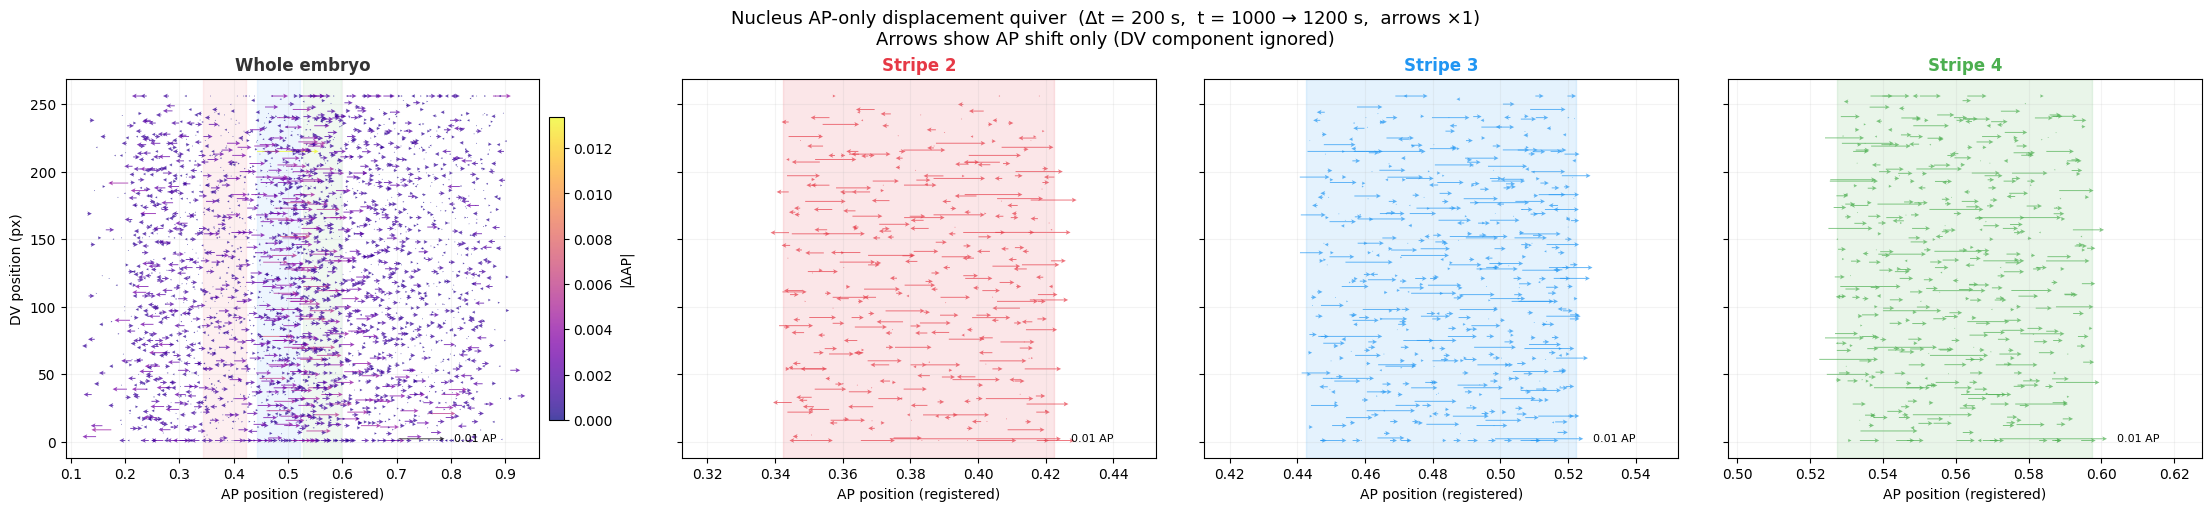

In [12]:

# ─────────────────────────────────────────────────────────────────────────────
# Figure D  –  Quiver plot of AP-only nucleus displacement at t = 1200 s
# ─────────────────────────────────────────────────────────────────────────────
# Only the AP axis displacement is shown (DV component set to zero).
# x = ap_registered, y = yPos (DV position, used for spatial context only).
# Stripe membership assigned from AP position at t=1200 (not median).

QUIVER_T1     = 1000   # start frame
QUIVER_T2     = 1200   # end frame
ARROW_MAGNIFY = 1     # multiply AP displacements for visibility

# ── Positions at both timepoints ─────────────────────────────────────────────
pos1 = (df[df['time'] == QUIVER_T1]
        .set_index('nucleus_id')[['ap_registered', 'yPos']]
        .rename(columns={'ap_registered': 'ap1', 'yPos': 'y1'}))

pos2 = (df[df['time'] == QUIVER_T2]
        .set_index('nucleus_id')[['ap_registered', 'yPos']]
        .rename(columns={'ap_registered': 'ap2', 'yPos': 'y2'}))

vel = pos1.join(pos2, how='inner').copy()
vel['dap']   = vel['ap2'] - vel['ap1']   # AP displacement only
vel['speed'] = vel['dap'].abs()          # magnitude = |ΔAP|

# Assign stripe from AP position *at t=1200*
def assign_stripe_at_t(ap):
    for s, (lo, hi) in STRIPE_RANGES.items():
        if lo <= ap <= hi:
            return s
    return 'other'

vel['stripe_t2'] = vel['ap2'].apply(assign_stripe_at_t)

print(f'Nuclei tracked t={QUIVER_T1}→{QUIVER_T2}: {len(vel):,} total')
print(f'AP displacement stats (ignoring DV):')
print(f'  dap  mean={vel["dap"].mean():.5f}  median={vel["dap"].median():.5f}  '
      f'max={vel["dap"].abs().max():.5f}')
for s in list(STRIPE_RANGES.keys()) + ['other']:
    n = (vel['stripe_t2'] == s).sum()
    lo_hi = f'  AP {STRIPE_RANGES[s][0]:.4f}–{STRIPE_RANGES[s][1]:.4f}' if s in STRIPE_RANGES else ''
    print(f'  {s}: {n:,} nuclei{lo_hi}')

# ── Quiver helper ─────────────────────────────────────────────────────────────
def draw_quiver_ap(ax, df_q, color, title, xlim=None, show_ylabel=False):
    if len(df_q) == 0:
        ax.set_title(title, fontsize=12)
        return

    X = df_q['ap1'].values
    Y = df_q['y1'].values
    U = df_q['dap'].values * ARROW_MAGNIFY
    V = np.zeros_like(U)              # no DV component

    if color == 'speed':
        q = ax.quiver(X, Y, U, V, df_q['speed'].values,
                      cmap='plasma', alpha=0.75,
                      width=0.002, headwidth=5, headlength=5, headaxislength=4,
                      rasterized=True)
        plt.colorbar(q, ax=ax, label='|ΔAP|', shrink=0.8, pad=0.02)
    else:
        q = ax.quiver(X, Y, U, V, color=color, alpha=0.7,
                      width=0.002, headwidth=5, headlength=5, headaxislength=4,
                      rasterized=True)

    ax.quiverkey(q, X=0.80, Y=0.05, U=0.01 * ARROW_MAGNIFY,
                 label='0.01 AP', labelpos='E', fontproperties={'size': 8})

    if color == 'speed':
        for s, (lo, hi) in STRIPE_RANGES.items():
            ax.axvspan(lo, hi, color=STRIPE_COLORS[s], alpha=0.08, zorder=0)
    else:
        stripe_key = next((k for k, v in STRIPE_LABELS.items() if v == title), None)
        if stripe_key:
            lo, hi = STRIPE_RANGES[stripe_key]
            ax.axvspan(lo, hi, color=color, alpha=0.12, zorder=0)

    ax.set_title(title, fontsize=12, fontweight='bold',
                 color='#333333' if title == 'Whole embryo' else color)
    ax.set_xlabel('AP position (registered)', fontsize=10)
    if show_ylabel:
        ax.set_ylabel('DV position (px)', fontsize=10)
    if xlim:
        ax.set_xlim(*xlim)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.15)

# ── Build panels ──────────────────────────────────────────────────────────────
stripe_keys = list(STRIPE_RANGES.keys())
stripe_xlims = {s: (STRIPE_RANGES[s][0] - 0.03, STRIPE_RANGES[s][1] + 0.03)
                for s in stripe_keys}

panel_data = [('Whole embryo', vel, 'speed', None)] + [
    (STRIPE_LABELS[s], vel[vel['stripe_t2'] == s], STRIPE_COLORS[s], stripe_xlims[s])
    for s in stripe_keys
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True,
                         layout='constrained',
                         gridspec_kw={'wspace': 0.08})

for i, (ax, (title, df_q, color, xlim)) in enumerate(zip(axes, panel_data)):
    draw_quiver_ap(ax, df_q, color, title, xlim=xlim, show_ylabel=(i == 0))

fig.suptitle(
    f'Nucleus AP-only displacement quiver  (Δt = {QUIVER_T2 - QUIVER_T1} s,  '
    f't = {QUIVER_T1} → {QUIVER_T2} s,  arrows ×{ARROW_MAGNIFY})\n'
    'Arrows show AP shift only (DV component ignored)',
    fontsize=13
)
plt.show()


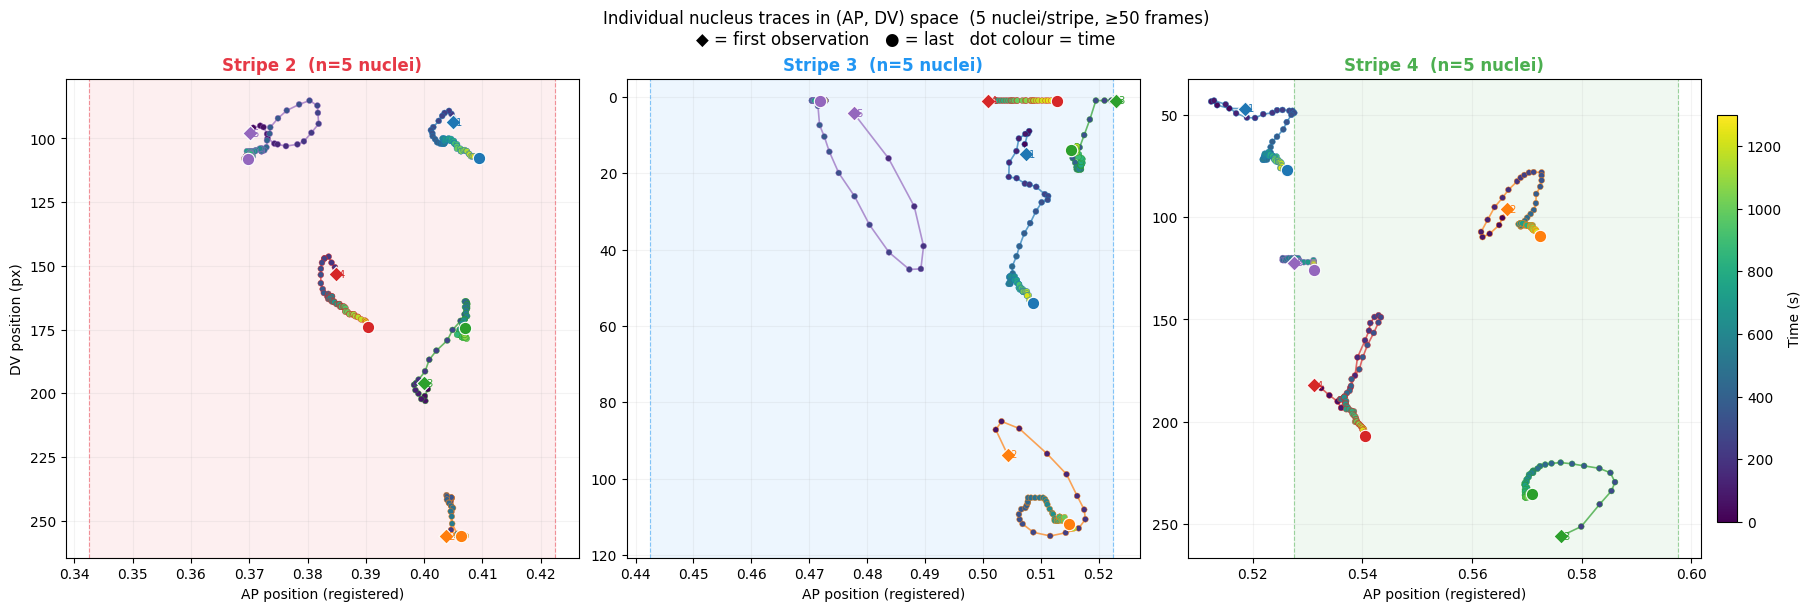

In [17]:

# ─────────────────────────────────────────────────────────────────────────────
# Figure E  –  Individual nucleus positional traces in (AP, DV) space
# ─────────────────────────────────────────────────────────────────────────────
# 5 randomly-selected, well-tracked nuclei per stripe.
# Each nucleus traces a path through (ap_registered, yPos) space over time.
# Lines connect consecutive timepoints chronologically.
# Dot colour encodes time (viridis: dark = early, bright = late).
# ◆ = first observation,  ● = last observation.

N_TRACE     = 5        # nuclei per stripe
MIN_FRAMES  = 50       # only pick nuclei with at least this many frames
RNG_TRACE   = np.random.default_rng(RNG_SEED + 99)

# Distinct colours for the 5 nuclei (colour-blind-friendly)
NUC_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout='constrained')

for ax, stripe in zip(axes, STRIPE_RANGES):
    lo, hi = STRIPE_RANGES[stripe]
    stripe_color = STRIPE_COLORS[stripe]

    # Pool of well-tracked nuclei in this stripe
    df_s = df_stripes[df_stripes['stripe'] == stripe]
    frame_counts = df_s.groupby('nucleus_id')['time'].count()
    eligible = frame_counts[frame_counts >= MIN_FRAMES].index.values

    if len(eligible) < N_TRACE:
        print(f'Warning: only {len(eligible)} eligible nuclei in {stripe}')
    pick = RNG_TRACE.choice(eligible, size=min(N_TRACE, len(eligible)), replace=False)

    # Shade the stripe AP band
    ax.axvspan(lo, hi, color=stripe_color, alpha=0.08, zorder=0)
    ax.axvline(lo, color=stripe_color, linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(hi, color=stripe_color, linewidth=0.8, linestyle='--', alpha=0.5)

    t_min = 0 #df_s['time'].min()
    t_max = 1300 #df_s['time'].max()
    df_s = df_s[df_s['time'].between(t_min, t_max)]

    for j, nid in enumerate(pick):
        traj = (df_s[df_s['nucleus_id'] == nid]
                [['time', 'ap_registered', 'yPos']]
                .sort_values('time')
                .reset_index(drop=True))

        c = NUC_COLORS[j % len(NUC_COLORS)]

        # Connecting line
        ax.plot(traj['ap_registered'], traj['yPos'],
                color=c, linewidth=1.2, alpha=0.7, zorder=1)

        # Dots coloured by time so direction is readable
        sc = ax.scatter(traj['ap_registered'], traj['yPos'],
                        c=traj['time'], cmap='viridis',
                        vmin=t_min, vmax=t_max,
                        s=18, zorder=2, linewidths=0.3, edgecolors=c)

        # Start marker ◆  and end marker ●
        ax.scatter(traj['ap_registered'].iloc[0],  traj['yPos'].iloc[0],
                   marker='D', s=60, color=c, zorder=4,
                   edgecolors='white', linewidths=0.8)
        ax.scatter(traj['ap_registered'].iloc[-1], traj['yPos'].iloc[-1],
                   marker='o', s=80, color=c, zorder=4,
                   edgecolors='white', linewidths=0.8)

        # Label the nucleus
        ax.text(traj['ap_registered'].iloc[0], traj['yPos'].iloc[0],
                f' {j+1}', fontsize=7, color=c, va='center', zorder=5)

    ax.set_title(f'{STRIPE_LABELS[stripe]}  (n={len(pick)} nuclei)',
                 fontsize=12, fontweight='bold', color=stripe_color)
    ax.set_xlabel('AP position (registered)', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('DV position (px)', fontsize=10)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.15)

# Shared time colorbar
cbar = fig.colorbar(sc, ax=axes[-1], label='Time (s)', shrink=0.85, pad=0.02)

fig.suptitle(
    f'Individual nucleus traces in (AP, DV) space  '
    f'(5 nuclei/stripe, ≥{MIN_FRAMES} frames)\n'
    '◆ = first observation   ● = last   dot colour = time',
    fontsize=12
)
plt.show()


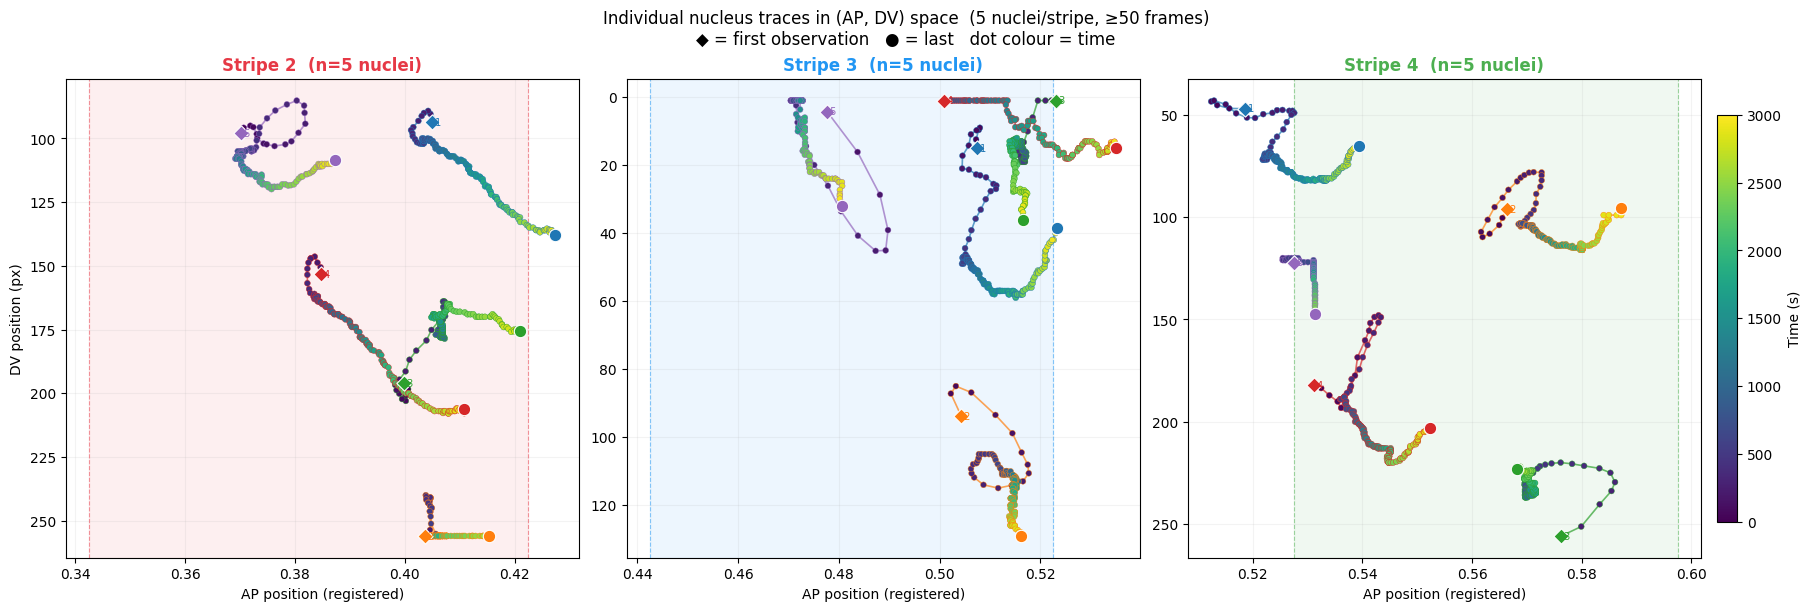

In [18]:

# ─────────────────────────────────────────────────────────────────────────────
# Figure E  –  Individual nucleus positional traces in (AP, DV) space
# ─────────────────────────────────────────────────────────────────────────────
# 5 randomly-selected, well-tracked nuclei per stripe.
# Each nucleus traces a path through (ap_registered, yPos) space over time.
# Lines connect consecutive timepoints chronologically.
# Dot colour encodes time (viridis: dark = early, bright = late).
# ◆ = first observation,  ● = last observation.

N_TRACE     = 5        # nuclei per stripe
MIN_FRAMES  = 50       # only pick nuclei with at least this many frames
RNG_TRACE   = np.random.default_rng(RNG_SEED + 99)

# Distinct colours for the 5 nuclei (colour-blind-friendly)
NUC_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout='constrained')

for ax, stripe in zip(axes, STRIPE_RANGES):
    lo, hi = STRIPE_RANGES[stripe]
    stripe_color = STRIPE_COLORS[stripe]

    # Pool of well-tracked nuclei in this stripe
    df_s = df_stripes[df_stripes['stripe'] == stripe]
    frame_counts = df_s.groupby('nucleus_id')['time'].count()
    eligible = frame_counts[frame_counts >= MIN_FRAMES].index.values

    if len(eligible) < N_TRACE:
        print(f'Warning: only {len(eligible)} eligible nuclei in {stripe}')
    pick = RNG_TRACE.choice(eligible, size=min(N_TRACE, len(eligible)), replace=False)

    # Shade the stripe AP band
    ax.axvspan(lo, hi, color=stripe_color, alpha=0.08, zorder=0)
    ax.axvline(lo, color=stripe_color, linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(hi, color=stripe_color, linewidth=0.8, linestyle='--', alpha=0.5)

    t_min = df_s['time'].min()
    t_max = df_s['time'].max()

    for j, nid in enumerate(pick):
        traj = (df_s[df_s['nucleus_id'] == nid]
                [['time', 'ap_registered', 'yPos']]
                .sort_values('time')
                .reset_index(drop=True))

        c = NUC_COLORS[j % len(NUC_COLORS)]

        # Connecting line
        ax.plot(traj['ap_registered'], traj['yPos'],
                color=c, linewidth=1.2, alpha=0.7, zorder=1)

        # Dots coloured by time so direction is readable
        sc = ax.scatter(traj['ap_registered'], traj['yPos'],
                        c=traj['time'], cmap='viridis',
                        vmin=t_min, vmax=t_max,
                        s=18, zorder=2, linewidths=0.3, edgecolors=c)

        # Start marker ◆  and end marker ●
        ax.scatter(traj['ap_registered'].iloc[0],  traj['yPos'].iloc[0],
                   marker='D', s=60, color=c, zorder=4,
                   edgecolors='white', linewidths=0.8)
        ax.scatter(traj['ap_registered'].iloc[-1], traj['yPos'].iloc[-1],
                   marker='o', s=80, color=c, zorder=4,
                   edgecolors='white', linewidths=0.8)

        # Label the nucleus
        ax.text(traj['ap_registered'].iloc[0], traj['yPos'].iloc[0],
                f' {j+1}', fontsize=7, color=c, va='center', zorder=5)

    ax.set_title(f'{STRIPE_LABELS[stripe]}  (n={len(pick)} nuclei)',
                 fontsize=12, fontweight='bold', color=stripe_color)
    ax.set_xlabel('AP position (registered)', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('DV position (px)', fontsize=10)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.15)

# Shared time colorbar
cbar = fig.colorbar(sc, ax=axes[-1], label='Time (s)', shrink=0.85, pad=0.02)

fig.suptitle(
    f'Individual nucleus traces in (AP, DV) space  '
    f'(5 nuclei/stripe, ≥{MIN_FRAMES} frames)\n'
    '◆ = first observation   ● = last   dot colour = time',
    fontsize=12
)
plt.show()


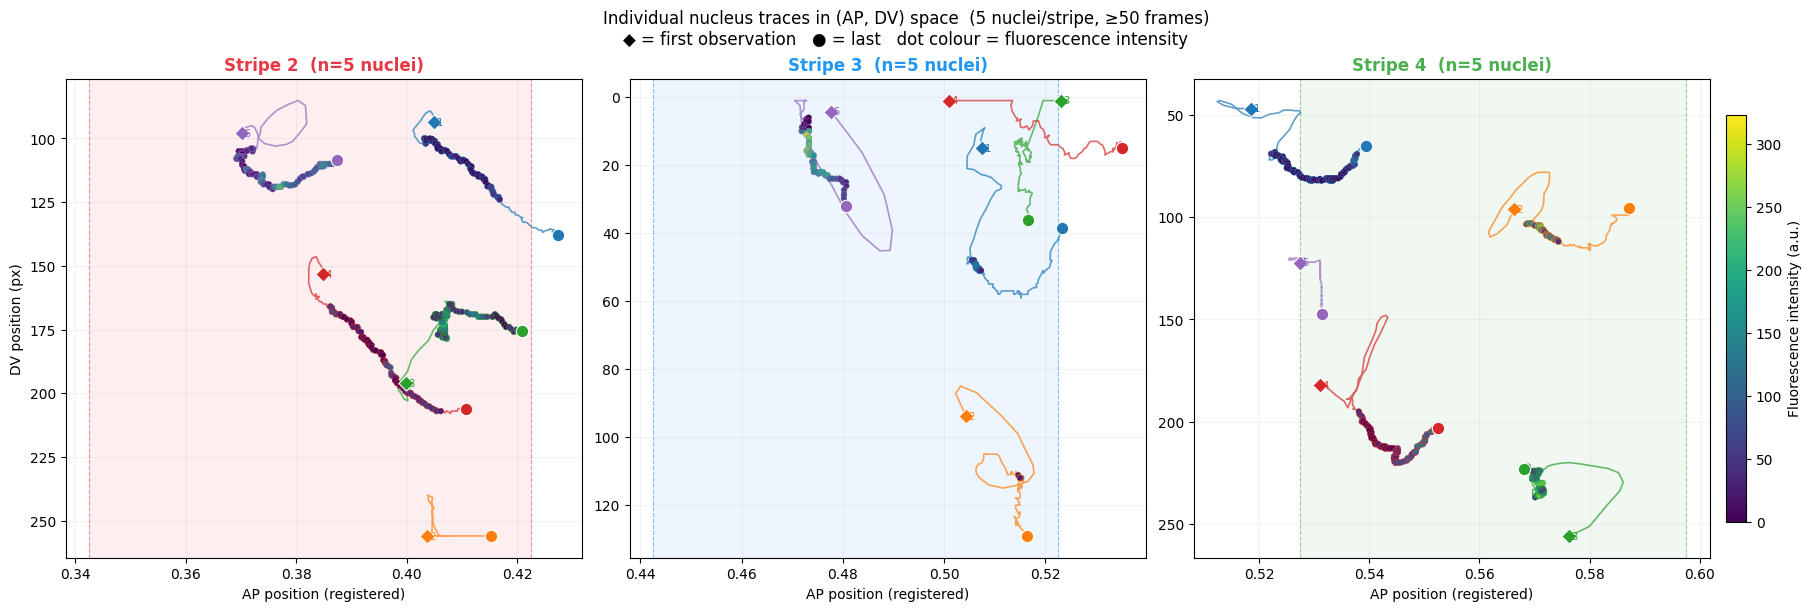

In [15]:

# ─────────────────────────────────────────────────────────────────────────────
# Figure E.2  –  Individual nucleus positional traces in (AP, DV) space
# ─────────────────────────────────────────────────────────────────────────────
# 5 randomly-selected, well-tracked nuclei per stripe.
# Each nucleus traces a path through (ap_registered, yPos) space over time.
# Lines connect consecutive timepoints chronologically.
# Dot colour encodes fluorescence intensity (viridis: dark = low, bright = high).
# ◆ = first observation,  ● = last observation.

N_TRACE     = 5        # nuclei per stripe
MIN_FRAMES  = 50       # only pick nuclei with at least this many frames
RNG_TRACE   = np.random.default_rng(RNG_SEED + 99)

# Distinct colours for the 5 nuclei (colour-blind-friendly)
NUC_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Global fluo range for a shared colorbar scale
fluo_min = df_stripes['fluo'].quantile(0.01)
fluo_max = df_stripes['fluo'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout='constrained')

for ax, stripe in zip(axes, STRIPE_RANGES):
    lo, hi = STRIPE_RANGES[stripe]
    stripe_color = STRIPE_COLORS[stripe]

    # Pool of well-tracked nuclei in this stripe
    df_s = df_stripes[df_stripes['stripe'] == stripe]
    frame_counts = df_s.groupby('nucleus_id')['time'].count()
    eligible = frame_counts[frame_counts >= MIN_FRAMES].index.values

    if len(eligible) < N_TRACE:
        print(f'Warning: only {len(eligible)} eligible nuclei in {stripe}')
    pick = RNG_TRACE.choice(eligible, size=min(N_TRACE, len(eligible)), replace=False)

    # Shade the stripe AP band
    ax.axvspan(lo, hi, color=stripe_color, alpha=0.08, zorder=0)
    ax.axvline(lo, color=stripe_color, linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(hi, color=stripe_color, linewidth=0.8, linestyle='--', alpha=0.5)

    for j, nid in enumerate(pick):
        traj = (df_s[df_s['nucleus_id'] == nid]
                [['time', 'ap_registered', 'yPos', 'fluo']]
                .sort_values('time')
                .reset_index(drop=True))

        c = NUC_COLORS[j % len(NUC_COLORS)]

        # Connecting line
        ax.plot(traj['ap_registered'], traj['yPos'],
                color=c, linewidth=1.2, alpha=0.7, zorder=1)

        # Dots coloured by fluorescence intensity
        sc = ax.scatter(traj['ap_registered'], traj['yPos'],
                        c=traj['fluo'], cmap='viridis',
                        vmin=fluo_min, vmax=fluo_max,
                        s=18, zorder=2, linewidths=0.3, edgecolors=c)

        # Start marker ◆  and end marker ●
        ax.scatter(traj['ap_registered'].iloc[0],  traj['yPos'].iloc[0],
                   marker='D', s=60, color=c, zorder=4,
                   edgecolors='white', linewidths=0.8)
        ax.scatter(traj['ap_registered'].iloc[-1], traj['yPos'].iloc[-1],
                   marker='o', s=80, color=c, zorder=4,
                   edgecolors='white', linewidths=0.8)

        # Label the nucleus
        ax.text(traj['ap_registered'].iloc[0], traj['yPos'].iloc[0],
                f' {j+1}', fontsize=7, color=c, va='center', zorder=5)

    ax.set_title(f'{STRIPE_LABELS[stripe]}  (n={len(pick)} nuclei)',
                 fontsize=12, fontweight='bold', color=stripe_color)
    ax.set_xlabel('AP position (registered)', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('DV position (px)', fontsize=10)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.15)

# Shared fluorescence colorbar
cbar = fig.colorbar(sc, ax=axes[-1], label='Fluorescence intensity (a.u.)', shrink=0.85, pad=0.02)

fig.suptitle(
    f'Individual nucleus traces in (AP, DV) space  '
    f'(5 nuclei/stripe, ≥{MIN_FRAMES} frames)\n'
    '◆ = first observation   ● = last   dot colour = fluorescence intensity',
    fontsize=12
)
plt.show()
